In [1]:
import seaborn as sns

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")


In [2]:
#parameters
db = "enamine10k_batch.sqlite"
TITLE = "Enamine10k"

In [3]:
# Parameters
db = "enamine_50k_batch.sqlite"
TITLE = "Enamine50k"


In [4]:
data, top_k = load_data(f"results/{db}", k_ratio=0.01)
K = len(top_k)
data.head()

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,Iteration,cluster,output_file_path,is_validation_result,...,output_file,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum
0,1,1,CC(=O)Nc1ccn(C2CCN(C(=O)c3ccccc3F)C2)n1,-9.1,-9.1,0.044775,0,0,None,0,...,enamine_50k_batch,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
1,2,1,Cc1n[nH]c(C)c1CCC(=O)N1CCN(C(=O)Cc2c[nH]c3cccc...,-8.9,-9.1,0.306841,1,0,None,0,...,enamine_50k_batch,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
2,3,1,CN1CCN(CC2CCN(C(=O)c3ccc4nccn4c3)CC2)CC1,-7.6,-9.1,0.306944,1,0,None,0,...,enamine_50k_batch,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
3,4,1,O=C(c1ccc([N+](=O)[O-])cc1O)N1CCC(CO)(Cc2ccc(F...,-9.8,-9.1,0.306951,1,0,None,0,...,enamine_50k_batch,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,True,1
4,5,1,CC(=O)NC(Cc1c[nH]c2cc(F)ccc12)C(=O)NCc1ncc2c(n...,-9.1,-9.1,0.316796,1,0,None,0,...,enamine_50k_batch,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,1


In [5]:
HUE_ORDER=sorted(data["Surrogate"].unique())

Text(0.5, 1.0, 'Enamine50k')

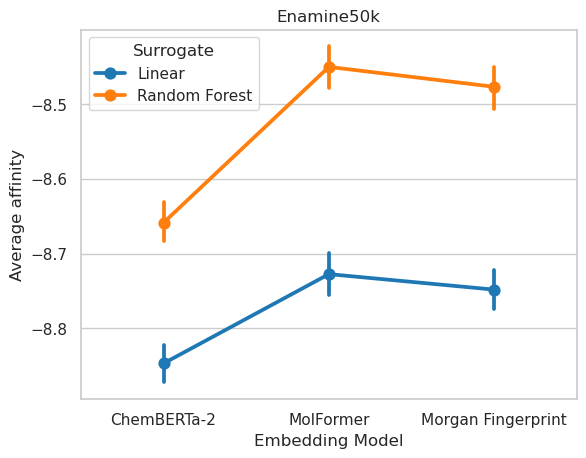

In [6]:
g = sns.pointplot(
    data,
    y="affinity",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    order=sorted(data["Embedding Model"].unique())
)
g.set_ylabel("Average affinity")
g.set_title(TITLE)

In [7]:
data.groupby(["Embedding Model", "Surrogate"])["is_top_k"].agg(lambda x: x.sum() / K)

Embedding Model     Surrogate    
ChemBERTa-2         Linear           0.782258
                    Random Forest    0.657258
MolFormer           Linear           0.743952
                    Random Forest    0.405242
Morgan Fingerprint  Linear           0.653226
                    Random Forest    0.395161
Name: is_top_k, dtype: float64

Text(0.5, 1.0, 'Enamine50k')

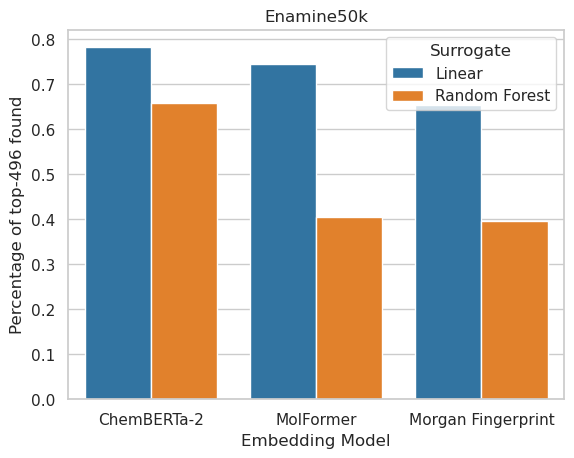

In [8]:
g = sns.barplot(
    data,
    y="is_top_k",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    errorbar=None,
    estimator = lambda x: x.sum() / K,
    order=sorted(data["Embedding Model"].unique()),
    dodge=True
)
g.set_ylabel(f"Percentage of top-{K} found")
g.set_title(TITLE)

/tmp/14358561.0.tmpdir/ipykernel_1639735/578230119.py:5: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


/tmp/14358561.0.tmpdir/ipykernel_1639735/578230119.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)
/tmp/14358561.0.tmpdir/ipykernel_1639735/578230119.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(labels)


Text(0.5, 0.98, 'Enamine50k')

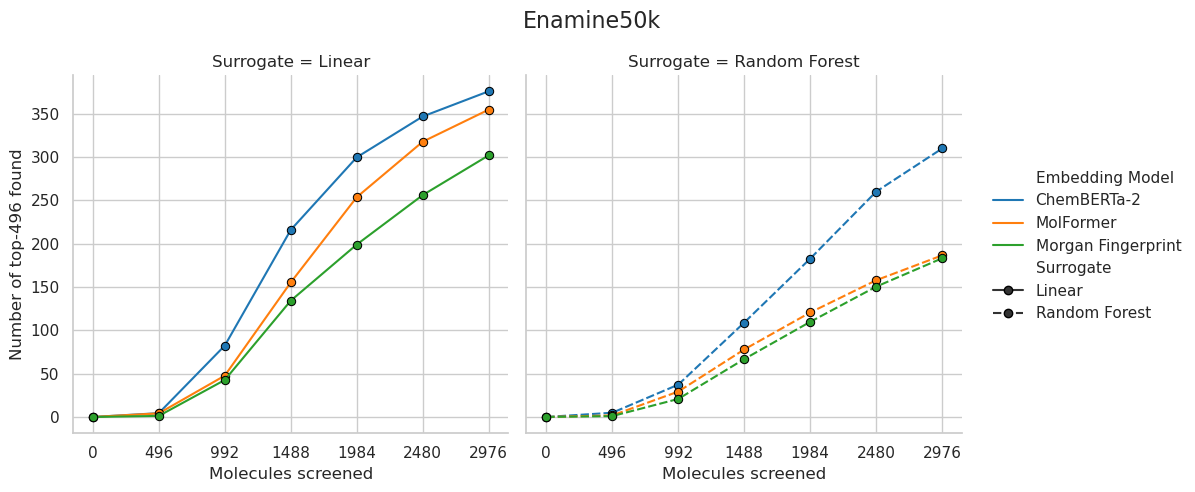

In [9]:
import matplotlib.pyplot as plt

use_markers = data["Iteration"].max() < 10

g = sns.relplot(
    data,
    y="is_top_k_cum",
    x="Iteration",
    hue="Embedding Model",
    col="Surrogate",
    col_order=["Linear", "Random Forest"],
    errorbar=None,
    kind="line",
    style="Surrogate",
    style_order=["Linear", "Random Forest"],
    markers="o" if use_markers else None,
    markeredgecolor="k",
    hue_order=sorted(data["Embedding Model"].unique())
)


g.set_xlabels("Molecules screened")
g.set_ylabels(f"Number of top-{K} found")
if use_markers:
    labels = [0] + sorted(data["Iteration"].unique() * len(top_k))
    def set_ticks(**kwargs):
        plt.gca().set_xticklabels(labels)

    g.map(set_ticks)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle(TITLE, fontsize=16)
